In [2]:
import numpy as np
import pandas as pd


In [3]:
df = pd.read_csv('data/kacha_river_clean.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df.head()

feature_cols = [
    'water_level_1day_lag', # уровень воды день назад
    't_avg_c', # средняя темепература
    'precip_mm', # осадки за сутки в мм
    'snow_pack_mm', # уровень снега в мм
    'snow_melt_mm', # переход снега в воду
    'evaporation_mm', # испарение воды
    'ice_jam_effect_cm', # ледовые заторы (повышают уроень воды)
    'level_trend_3d', # тренд уровня воды за 3 дня (насколько повышалось/уменьшалось)
    'temp_trend_3d' # тренд температуры за 3 дня
]

In [4]:
def prepare_data(df, feature_cols, forecast_horizon=1):
    df_prep = df.copy()
    df_prep['target'] = df_prep['water_level_cm'].shift(-forecast_horizon)
    df_prep = df_prep.dropna().reset_index(drop=True)
    
    X = df_prep[feature_cols].values
    y = df_prep['target'].values
    dates = df_prep['date'].values
    
    return X, y, dates

In [5]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor


def optimize_xgboost(X_train, y_train):
    base_params = {
        'objective': 'reg:squarederror',
        'random_state': 42,
        'n_jobs': -1
    }

    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.03, 0.05, 0.07],
        'subsample': [0.7, 0.8],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'min_child_weight': [1, 3],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [0, 0.1, 1]
    }

    tscv = TimeSeriesSplit(n_splits=3)

    
    grid_search = GridSearchCV(
        XGBRegressor(**base_params),
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        verbose=1,
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"\nЛучшие параметры:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param}: {value}")
    print(f"Лучший MAE (CV): {-grid_search.best_score_:.3f}")
    
    return grid_search.best_estimator_, grid_search.best_params_

In [6]:
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler


def train_and_evaluate(df, feature_cols, forecast_horizon=1, test_size=90):
    X, y, dates = prepare_data(df, feature_cols, forecast_horizon)
    
    train_size = len(X) - test_size
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    test_dates = dates[train_size:]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model, best_params = optimize_xgboost(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_test_pred)
    print(f"  MAE:  {mae:.2f} см")
    
    model = {
        'horizon': forecast_horizon,
        'model': model,
        'scaler': scaler,
        'best_params': best_params,
        'MAE': mae,
        'predictions': y_test_pred,
        'actual': y_test,
        'dates': test_dates,
        'feature_cols': feature_cols
    }
    
    return model

In [ ]:
import joblib
horizons = [1, 3, 7]
results = {}

for horizon in horizons:
    results[horizon] = train_and_evaluate(df, feature_cols, forecast_horizon=horizon, test_size=90)

for horizon, res in results.items():
    model_data = {
        'model': res['model'],
        'scaler': res['scaler'],
        'feature_cols': res['feature_cols'],
        'best_params': res['best_params']
    }
    joblib.dump(model_data, f'xgboost_model_{horizon}day.pkl')
    print(f"Модель для {horizon} дня сохранена")

print("\nВсе модели успешно сохранены!")

Fitting 3 folds for each of 2916 candidates, totalling 8748 fits


Можешь запустить чисто эту штуку, чтобы не тратить время на обучение


Горизонт 1 день:
  MAE: 5.68 см

Горизонт 3 день:
  MAE: 6.21 см

Горизонт 7 день:
  MAE: 5.43 см


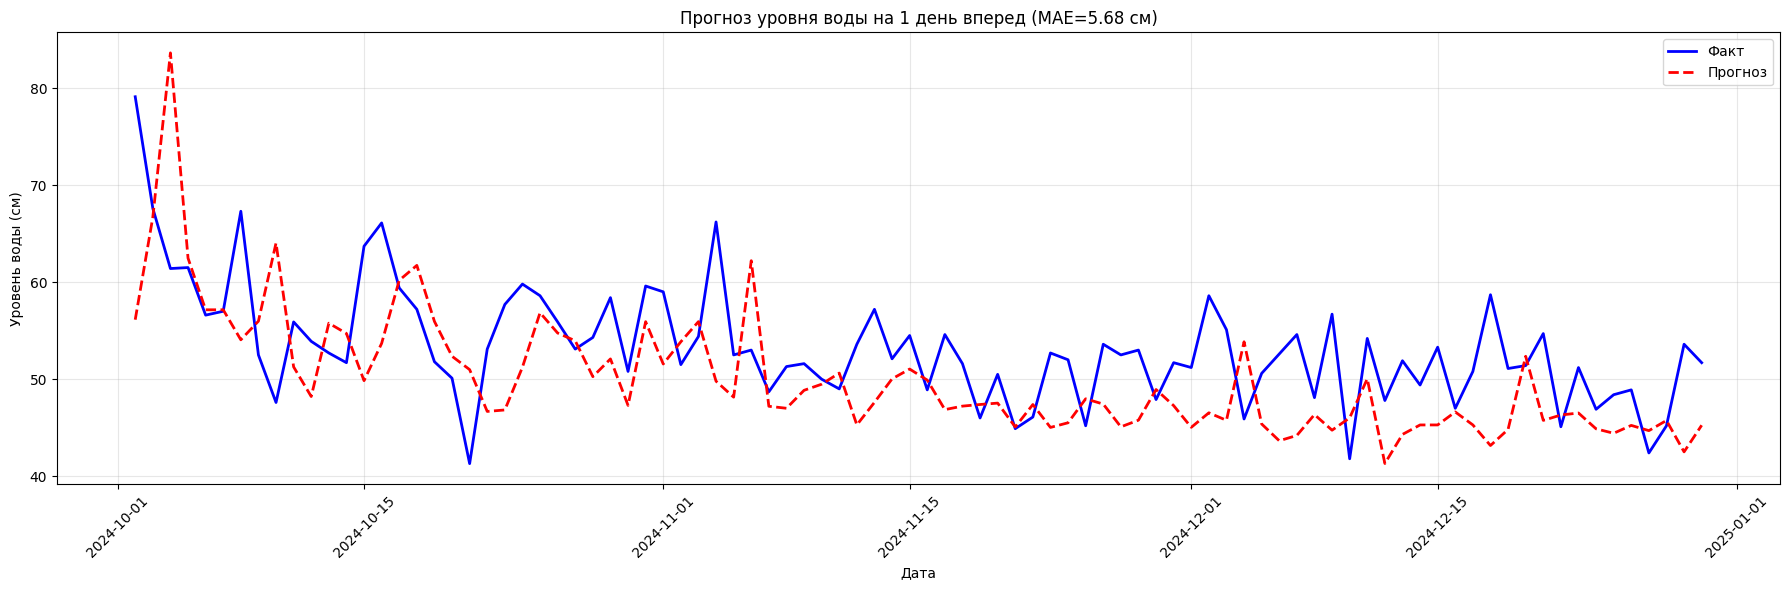

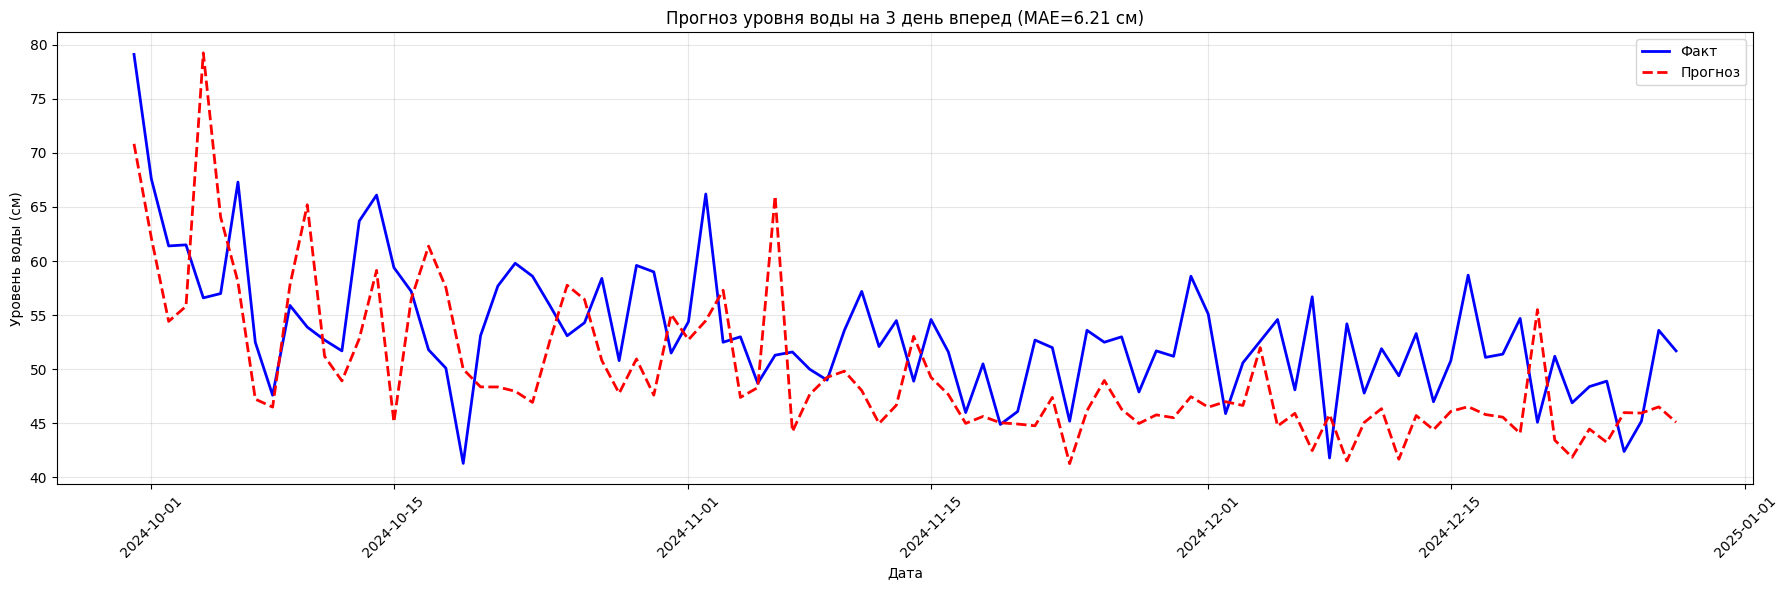

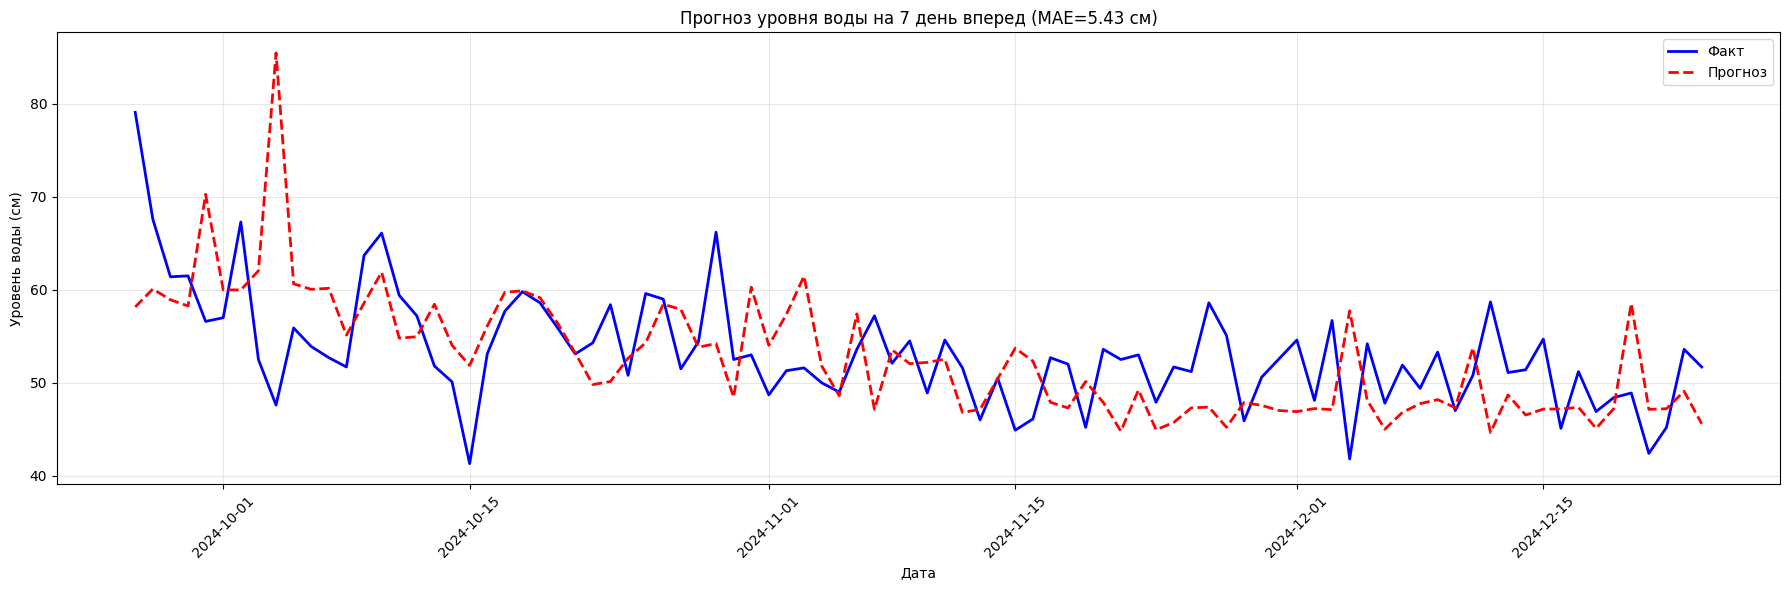

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_error

df = pd.read_csv('data/kacha_river_clean.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

feature_cols = [
    'water_level_1day_lag', # уровень воды день назад
    't_avg_c', # средняя темепература
    'precip_mm', # осадки за сутки в мм
    'snow_pack_mm', # уровень снега в мм
    'snow_melt_mm', # переход снега в воду
    'evaporation_mm', # испарение воды
    'ice_jam_effect_cm', # ледовые заторы (повышают уроень воды)
    'level_trend_3d', # тренд уровня воды за 3 дня (насколько повышалось/уменьшалось)
    'temp_trend_3d' # тренд температуры за 3 дня
]

results = {}

for horizon in [1, 3, 7]:
    filename = f'xgboost_model_{horizon}day.pkl'
    model_data = joblib.load(filename)
    results[horizon] = {
            'model': model_data['model'],
            'scaler': model_data['scaler'],
            'feature_cols': model_data['feature_cols'],
            'best_params': model_data['best_params']
        }

test_size = 90
for horizon in [1, 3, 7]:
    if horizon not in results:
        continue
    
    df_prep = df.copy()
    df_prep['target'] = df_prep['water_level_cm'].shift(-horizon)
    df_prep = df_prep.dropna().reset_index(drop=True)
    
    X = df_prep[feature_cols].values
    y = df_prep['target'].values
    dates = df_prep['date'].values
    
    train_size = len(X) - test_size
    X_test = X[train_size:]
    y_test = y[train_size:]
    test_dates = dates[train_size:]
    
    X_test_scaled = results[horizon]['scaler'].transform(X_test)
    y_pred = results[horizon]['model'].predict(X_test_scaled)
    
    results[horizon]['predictions'] = y_pred
    results[horizon]['actual'] = y_test
    results[horizon]['dates'] = test_dates
    results[horizon]['MAE'] = mean_absolute_error(y_test, y_pred)
    
    print(f"\nГоризонт {horizon} день:")
    print(f"  MAE: {results[horizon]['MAE']:.2f} см")

for horizon in [1, 3, 7]:
    plt.figure(figsize=(18, 6))
    res = results[horizon]
    dates = pd.to_datetime(res['dates'])
    
    plt.plot(dates, res['actual'], 'b-', label='Факт', linewidth=2)
    plt.plot(dates, res['predictions'], 'r--', label='Прогноз', linewidth=2)
    plt.title(f'Прогноз уровня воды на {horizon} день вперед (MAE={res["MAE"]:.2f} см)')
    plt.xlabel('Дата')
    plt.ylabel('Уровень воды (см)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()